In [1]:
import sys
import os

# Add parent directory to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting theme
sns.set_theme(style="whitegrid")

# Load featured dataset (fall back to processed/cleaned data if featured isn't generated yet)
data_path = "../data/processed/featured_data.csv"
if not os.path.exists(data_path):
    data_path = "../data/processed/cleaned_data.csv"
    
df = pd.read_csv(data_path)
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1000, 21)


,timestamp,segment_id,road_type,speed_limit,vehicle_count,congestion_level,average_speed,rainfall_mm,visibility_m,pothole_count,...,sudden_braking_events,hour_of_day,is_peak_hour,risk_score,speed_ratio,traffic_pressure,weather_hazard_score,infrastructure_risk,day_of_week,is_weekend
0,2026-01-01 00:00:00,SEG_007,highway,80,114,0.30,53.13,30.861529,61.49,2,...,2,0,0,33.69,0.664125,0.3420,80.0,35.0,3,0
1,2026-01-01 01:00:00,SEG_015,city_road,50,107,0.31,32.40,0.000000,3588.94,7,...,2,1,0,29.90,0.648000,0.3317,10.0,17.5,3,0
2,2026-01-01 02:00:00,SEG_011,city_road,50,63,0.15,34.98,30.861529,61.49,3,...,1,2,0,20.42,0.699600,0.0945,80.0,7.5,3,0
3,2026-01-01 03:00:00,SEG_008,highway,80,297,0.66,27.83,0.000000,3588.94,2,...,1,3,0,30.88,0.347875,1.9602,10.0,5.0,3,0
4,2026-01-01 04:00:00,SEG_007,highway,80,190,0.50,40.15,0.000000,3588.94,1,...,1,4,0,26.24,0.501875,0.9500,10.0,2.5,3,0


C:\Users\prade\AppData\Local\Temp\ipykernel_9700\2891709810.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='road_type', y='risk_score', data=df, palette='Set2')


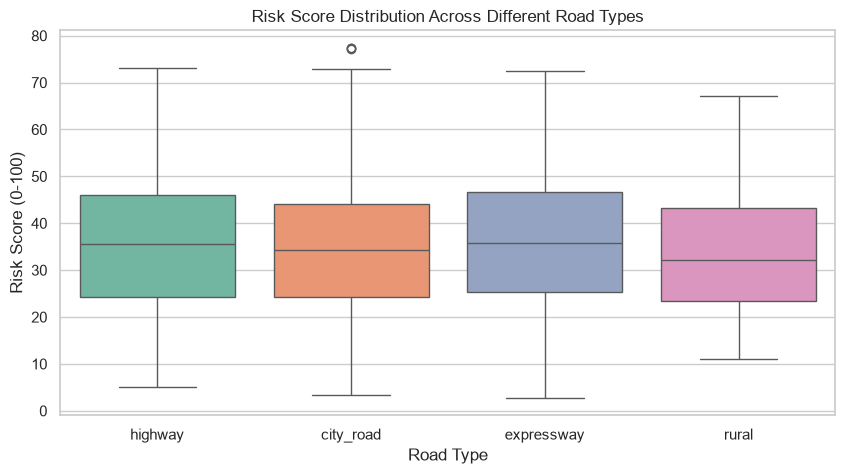

In [2]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='road_type', y='risk_score', data=df, palette='Set2')
plt.title("Risk Score Distribution Across Different Road Types")
plt.xlabel("Road Type")
plt.ylabel("Risk Score (0-100)")
plt.show()

In [3]:
import sys
import os

# Add parent directory to path so we can import from src
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
from src.data_cleaner import clean_traffic_data

# Run the cleaning pipeline programmatically with correct paths from notebooks folder
cleaned_df = clean_traffic_data(
    input_path="../data/raw/synthetic_traffic_data.csv", 
    output_path="../data/processed/cleaned_data.csv"
)

# Display sample of cleaned data
cleaned_df.head()

[INFO] Loading raw data from ../data/raw/synthetic_traffic_data.csv...
Initial row count: 1000
Rows after removing duplicates: 1000
[SUCCESS] Cleaned data saved to ../data/processed/cleaned_data.csv
Final row count after cleaning: 1000 (Removed 0 anomalous rows)


,timestamp,segment_id,road_type,speed_limit,vehicle_count,congestion_level,average_speed,rainfall_mm,visibility_m,pothole_count,waterlogging,sudden_braking_events,hour_of_day,is_peak_hour,risk_score
0,2026-01-01 00:00:00,SEG_007,highway,80,114,0.30,53.13,30.861529,61.49,2,1,2,0,0,33.69
1,2026-01-01 01:00:00,SEG_015,city_road,50,107,0.31,32.40,0.000000,3588.94,7,0,2,1,0,29.90
2,2026-01-01 02:00:00,SEG_011,city_road,50,63,0.15,34.98,30.861529,61.49,3,0,1,2,0,20.42
3,2026-01-01 03:00:00,SEG_008,highway,80,297,0.66,27.83,0.000000,3588.94,2,0,1,3,0,30.88
4,2026-01-01 04:00:00,SEG_007,highway,80,190,0.50,40.15,0.000000,3588.94,1,0,1,4,0,26.24


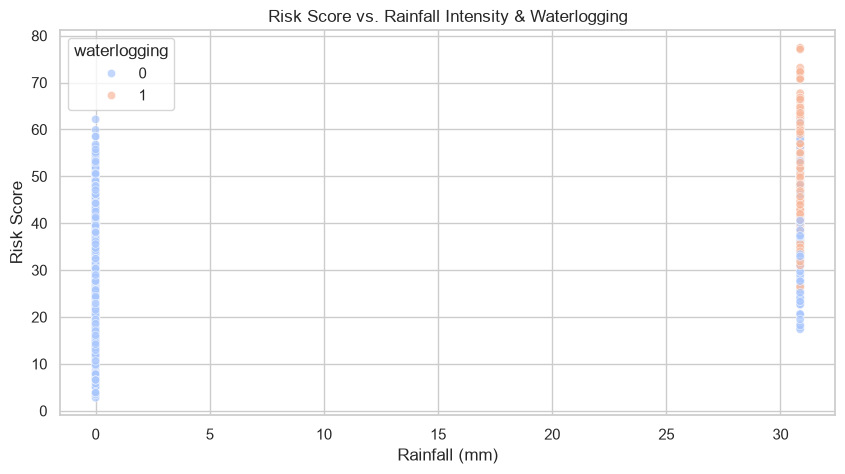

In [4]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='rainfall_mm', y='risk_score', hue='waterlogging', data=df, palette='coolwarm', alpha=0.7)
plt.title("Risk Score vs. Rainfall Intensity & Waterlogging")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Risk Score")
plt.show()